In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
customers = pd.read_csv('dataset/olist_customers_dataset.csv')
orders = pd.read_csv('dataset/olist_orders_dataset.csv', parse_dates=['order_purchase_timestamp','order_approved_at','order_delivered_customer_date'])
order_items = pd.read_csv('dataset/olist_order_items_dataset.csv')
payments = pd.read_csv('dataset/olist_order_payments_dataset.csv')

In [3]:
order_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [21]:
# Aggregate payments
payments_agg = payments.groupby('order_id')['payment_value'].sum().reset_index()

#Aggregate item prices
prices_agg = order_items.groupby('order_id')['price'].sum().reset_index()

#  Merge with orders
orders_full = orders.merge(payments_agg, on='order_id', how='left')
orders_full = orders_full.merge(prices_agg, on='order_id', how='left')

# Compute final order value
orders_full['order_value'] = orders_full['payment_value'].fillna(orders_full['price']).fillna(0)

# Filter cancelled and zero-value orders
orders_full = orders_full[orders_full['order_status'] != 'canceled']
orders_full = orders_full[orders_full['order_value'] > 0]

# Optional: merge with customers table
orders_full = orders_full.merge(customers, on='customer_id', how='left')


In [22]:
orders_full['order_purchase_timestamp'] = pd.to_datetime(orders_full['order_purchase_timestamp'])
orders_full = orders_full.dropna(subset=['customer_id','order_purchase_timestamp','order_value'])
orders_full = orders_full[orders_full['order_value'] > 0]

In [23]:
customer_agg = orders_full.groupby('customer_id').agg({
    'order_value': ['sum', 'mean', 'count'],
    'order_purchase_timestamp': ['min', 'max']
})

customer_agg.columns = ['monetary_sum','monetary_avg','frequency','first_order','last_order']
customer_agg = customer_agg.reset_index()
customer_agg['recency_days'] = (customer_agg['last_order'] - customer_agg['first_order']).dt.days
customer_agg['T_days'] = (orders_full['order_purchase_timestamp'].max() - customer_agg['first_order']).dt.days

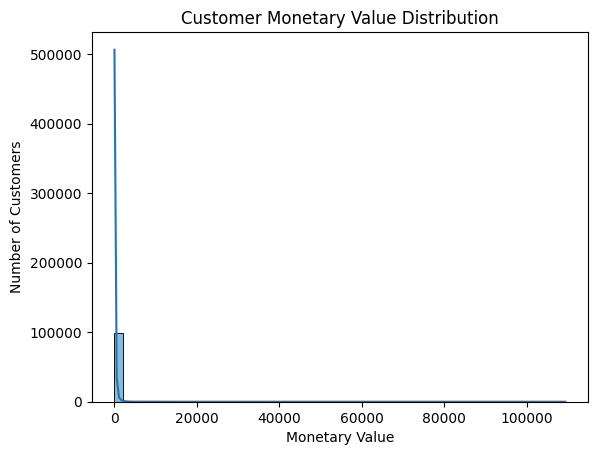

In [42]:
sns.histplot(customer_agg['monetary_sum'], bins=50, kde=True)
plt.title("Customer Monetary Value Distribution")
plt.xlabel("Monetary Value")
plt.ylabel("Number of Customers")
plt.show()

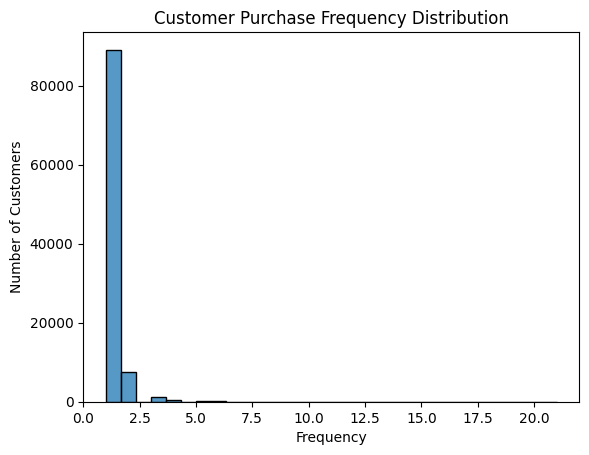

In [41]:
sns.histplot(customer_agg['frequency'], bins=30, kde=False)
plt.title("Customer Purchase Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

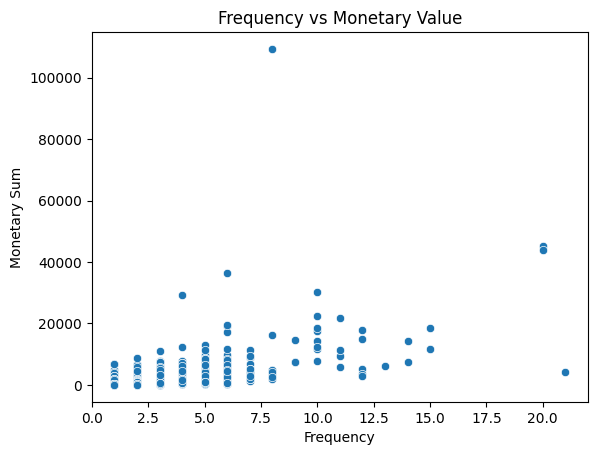

In [38]:
sns.scatterplot(x='frequency', y='monetary_sum', data=customer_agg)
plt.title("Frequency vs Monetary Value")
plt.xlabel("Frequency")
plt.ylabel("Monetary Sum")
plt.show()

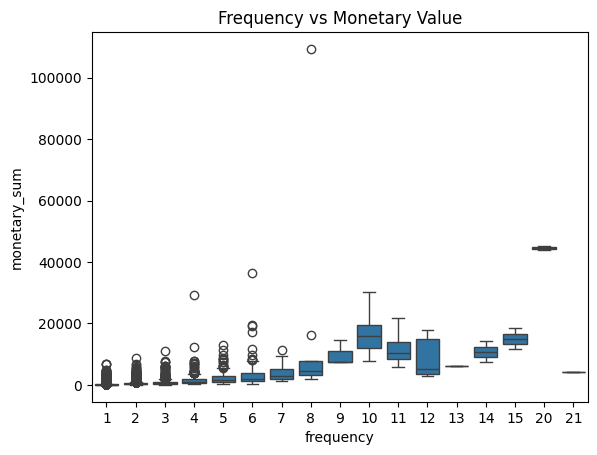

In [39]:
sns.boxplot(x='frequency', y='monetary_sum', data=customer_agg)
plt.title("Frequency vs Monetary Value")
plt.show()

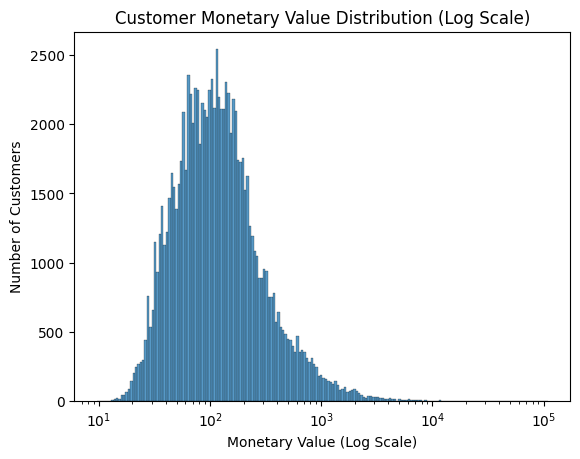

In [40]:
sns.histplot(customer_agg['monetary_sum'], log_scale=True)
plt.title("Customer Monetary Value Distribution (Log Scale)")
plt.xlabel("Monetary Value (Log Scale)")
plt.ylabel("Number of Customers")
plt.show()

In [29]:
customer_agg['CLV_baseline'] = customer_agg['monetary_avg'] * customer_agg['frequency']

In [30]:
X = customer_agg[['frequency','monetary_avg','recency_days','T_days']]
y = customer_agg['CLV_baseline']  

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [34]:
rf = RandomForestRegressor(random_state=42)
params = {'n_estimators':[100,200],'max_depth':[5,10,None]}
grid = GridSearchCV(rf, params, cv=3, scoring='r2')
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

In [36]:
y_pred = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse}, R2: {r2}")

RMSE: 12580.360844859177, R2: 0.9599723739883507


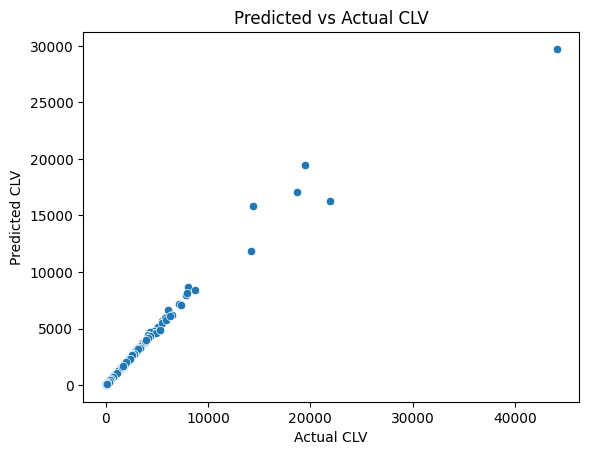

In [37]:
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Predicted vs Actual CLV")
plt.show()

In [43]:
# Save the trained Random Forest model
joblib.dump(best_model, 'rf_clv_model.pkl')

['rf_clv_model.pkl']